# Análise de Desempenho — Pipeline de Streaming BTC/USDT

**Disciplina:** Big Data  
**Pipeline:** Binance WebSocket → Kafka → Spark Structured Streaming

Este notebook analisa as métricas de desempenho coletadas durante os experimentos,
variando número de partições do Kafka e tamanho da janela de agregação.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

# Força o caminho relativo a partir de onde o notebook está executando
METRICS_DIR = Path.cwd().parent / "metrics"

# Cria o diretório (e diretórios pai, se necessário) caso ele não exista
METRICS_DIR.mkdir(parents=True, exist_ok=True)

# Carrega todos os CSVs de performance
perf_files = sorted(METRICS_DIR.glob("performance_*.csv"))
candle_files = sorted(METRICS_DIR.glob("candles_*.csv"))

print(f"Diretório de métricas resolvido: {METRICS_DIR}")
print(f"Arquivos de performance encontrados: {len(perf_files)}")
for f in perf_files:
    print(f"  - {f.name}")

print(f"\nArquivos de candles encontrados: {len(candle_files)}")
for f in candle_files:
    print(f"  - {f.name}")

Diretório de métricas resolvido: /home/jovyan/work/metrics
Arquivos de performance encontrados: 2
  - performance_default.csv
  - performance_p1_w15_r1.csv

Arquivos de candles encontrados: 2
  - candles_default.csv
  - candles_p1_w15_r1.csv


In [2]:
# Concatena todos os CSVs de performance num único DataFrame
dfs_perf = []
for f in perf_files:
    try:
        df = pd.read_csv(f)
        if not df.empty:
            dfs_perf.append(df)
    except Exception as e:
        print(f"Erro ao ler {f.name}: {e}")

if dfs_perf:
    perf = pd.concat(dfs_perf, ignore_index=True)
    perf["timestamp"] = pd.to_datetime(perf["timestamp"])
    # Extrai partições e janela do label
    perf["partitions"] = perf["experiment_label"].str.extract(r'p(\d+)').astype(float)
    perf["window_s"] = perf["experiment_label"].str.extract(r'w(\d+)').astype(float)
    print(f"Total de batches registrados: {len(perf)}")
    print(f"Experimentos: {perf['experiment_label'].unique()}")
    perf.head()
else:
    print("AVISO: Nenhum dado de performance encontrado. Rode os experimentos primeiro.")
    perf = pd.DataFrame()

Total de batches registrados: 7
Experimentos: ['p1_w15_r1']


## 1. Throughput por Configuração

Compara a vazão (trades processados por segundo) entre diferentes números de partições.

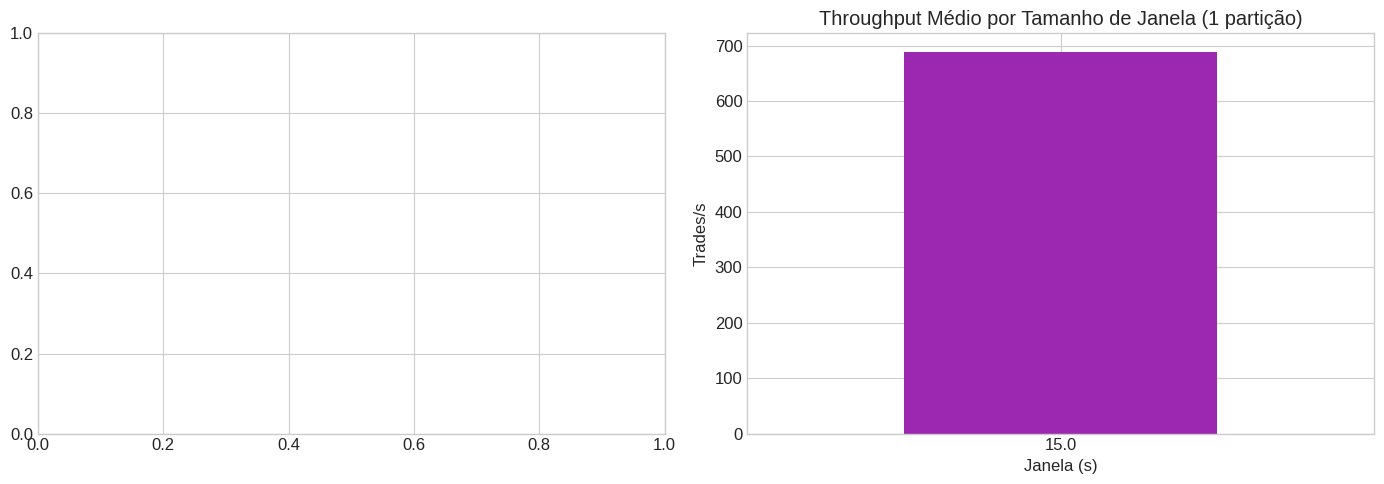

Salvo em: metrics/throughput_comparison.png


In [3]:
if not perf.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Throughput médio por número de partições (janela fixa = 10s)
    perf_w10 = perf[perf["window_s"] == 10]
    if not perf_w10.empty:
        throughput_by_part = perf_w10.groupby("partitions")["throughput_trades_per_sec"].mean()
        throughput_by_part.plot(kind="bar", ax=axes[0], color=["#2196F3", "#4CAF50", "#FF9800"])
        axes[0].set_title("Throughput Médio por Partições (janela=10s)")
        axes[0].set_xlabel("Partições")
        axes[0].set_ylabel("Trades/s")
        axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

    # Throughput médio por tamanho de janela (1 partição)
    perf_p1 = perf[perf["partitions"] == 1]
    if not perf_p1.empty:
        throughput_by_win = perf_p1.groupby("window_s")["throughput_trades_per_sec"].mean()
        throughput_by_win.plot(kind="bar", ax=axes[1], color=["#9C27B0", "#2196F3", "#E91E63"])
        axes[1].set_title("Throughput Médio por Tamanho de Janela (1 partição)")
        axes[1].set_xlabel("Janela (s)")
        axes[1].set_ylabel("Trades/s")
        axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

    plt.tight_layout()
    plt.savefig(METRICS_DIR / "throughput_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Salvo em: metrics/throughput_comparison.png")

## 2. Distribuição de Latência

Latência fim-a-fim (event time → processamento) com percentis p50, p95 e p99.

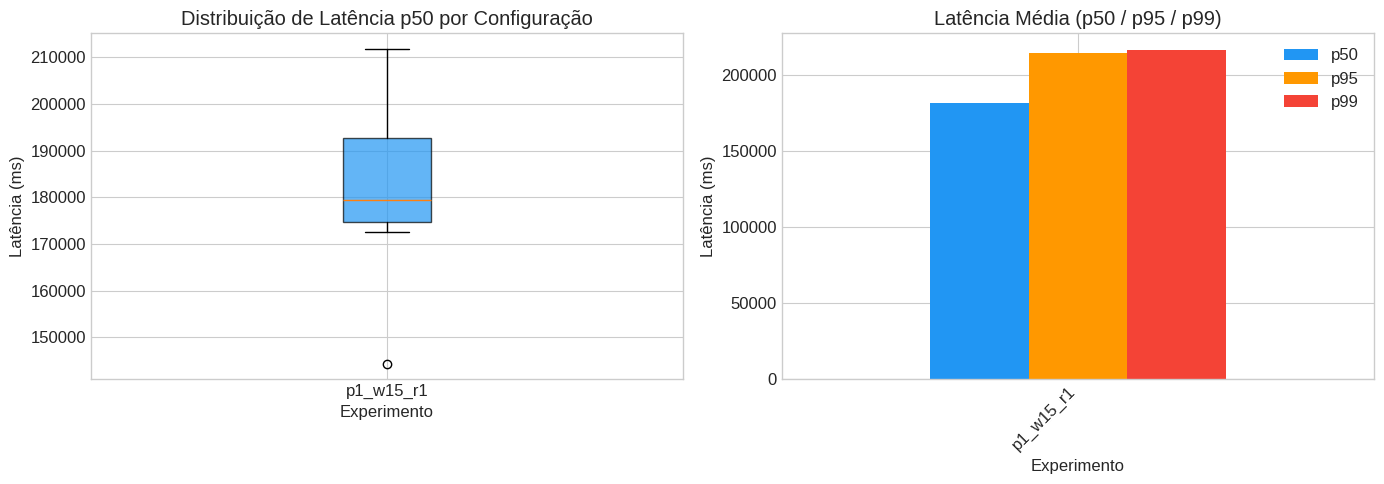

Salvo em: metrics/latency_distribution.png


In [4]:
if not perf.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Boxplot de latência por configuração
    experiments = perf["experiment_label"].unique()
    latency_data = [perf[perf["experiment_label"] == e]["latency_p50_ms"].dropna().values
                    for e in experiments]
    latency_data = [d for d in latency_data if len(d) > 0]
    valid_labels = [e for e, d in zip(experiments,
                    [perf[perf["experiment_label"] == e]["latency_p50_ms"].dropna().values
                     for e in experiments]) if len(d) > 0]

    if latency_data:
        bp = axes[0].boxplot(latency_data, labels=valid_labels, patch_artist=True)
        colors = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0", "#E91E63"]
        for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        axes[0].set_title("Distribuição de Latência p50 por Configuração")
        axes[0].set_ylabel("Latência (ms)")
        axes[0].set_xlabel("Experimento")

    # Comparação p50 vs p95 vs p99 por configuração
    summary = perf.groupby("experiment_label").agg({
        "latency_p50_ms": "mean",
        "latency_p95_ms": "mean",
        "latency_p99_ms": "mean"
    })
    if not summary.empty:
        summary.plot(kind="bar", ax=axes[1], color=["#2196F3", "#FF9800", "#F44336"])
        axes[1].set_title("Latência Média (p50 / p95 / p99)")
        axes[1].set_ylabel("Latência (ms)")
        axes[1].set_xlabel("Experimento")
        axes[1].legend(["p50", "p95", "p99"])
        axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")

    plt.tight_layout()
    plt.savefig(METRICS_DIR / "latency_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Salvo em: metrics/latency_distribution.png")

## 3. Latência ao Longo do Tempo

Evolução temporal da latência durante cada experimento.

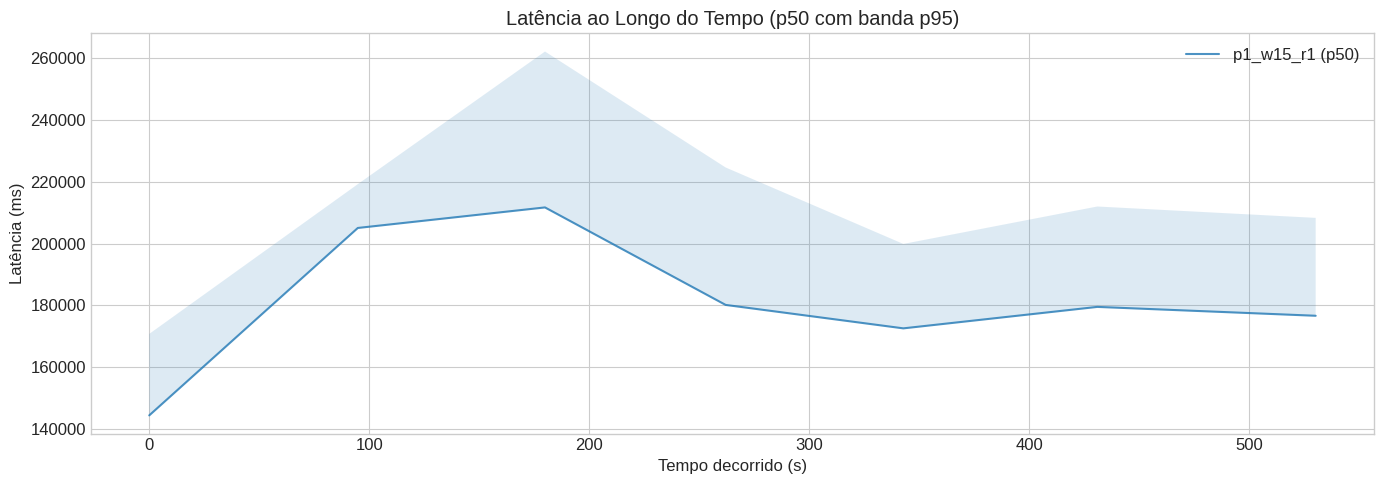

Salvo em: metrics/latency_timeline.png


In [5]:
if not perf.empty:
    fig, ax = plt.subplots(figsize=(14, 5))

    for label in perf["experiment_label"].unique():
        subset = perf[perf["experiment_label"] == label].sort_values("timestamp")
        # Normaliza o tempo para começar em 0
        t0 = subset["timestamp"].iloc[0]
        elapsed = (subset["timestamp"] - t0).dt.total_seconds()
        ax.plot(elapsed, subset["latency_p50_ms"], label=f"{label} (p50)", alpha=0.8)
        ax.fill_between(elapsed, subset["latency_p50_ms"], subset["latency_p95_ms"],
                        alpha=0.15)

    ax.set_title("Latência ao Longo do Tempo (p50 com banda p95)")
    ax.set_xlabel("Tempo decorrido (s)")
    ax.set_ylabel("Latência (ms)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(METRICS_DIR / "latency_timeline.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Salvo em: metrics/latency_timeline.png")

## 4. Candles OHLCV + Indicadores Técnicos

Gráfico de velas (candlestick) com EMA(9) e RSI(14).

In [6]:
# Carrega candles
dfs_candles = []
for f in candle_files:
    try:
        df = pd.read_csv(f)
        if not df.empty:
            dfs_candles.append(df)
    except Exception as e:
        print(f"Erro ao ler {f.name}: {e}")

if dfs_candles:
    candles = pd.concat(dfs_candles, ignore_index=True)
    candles["window_start"] = pd.to_datetime(candles["window_start"])
    candles["window_end"] = pd.to_datetime(candles["window_end"])
    for col_name in ["open", "high", "low", "close", "volume", "buy_volume", "sell_volume", "ema_9", "rsi_14"]:
        candles[col_name] = pd.to_numeric(candles[col_name], errors="coerce")
    print(f"Total de candles: {len(candles)}")
    candles.tail(10)
else:
    print("AVISO: Nenhum dado de candles encontrado.")
    candles = pd.DataFrame()

Total de candles: 39


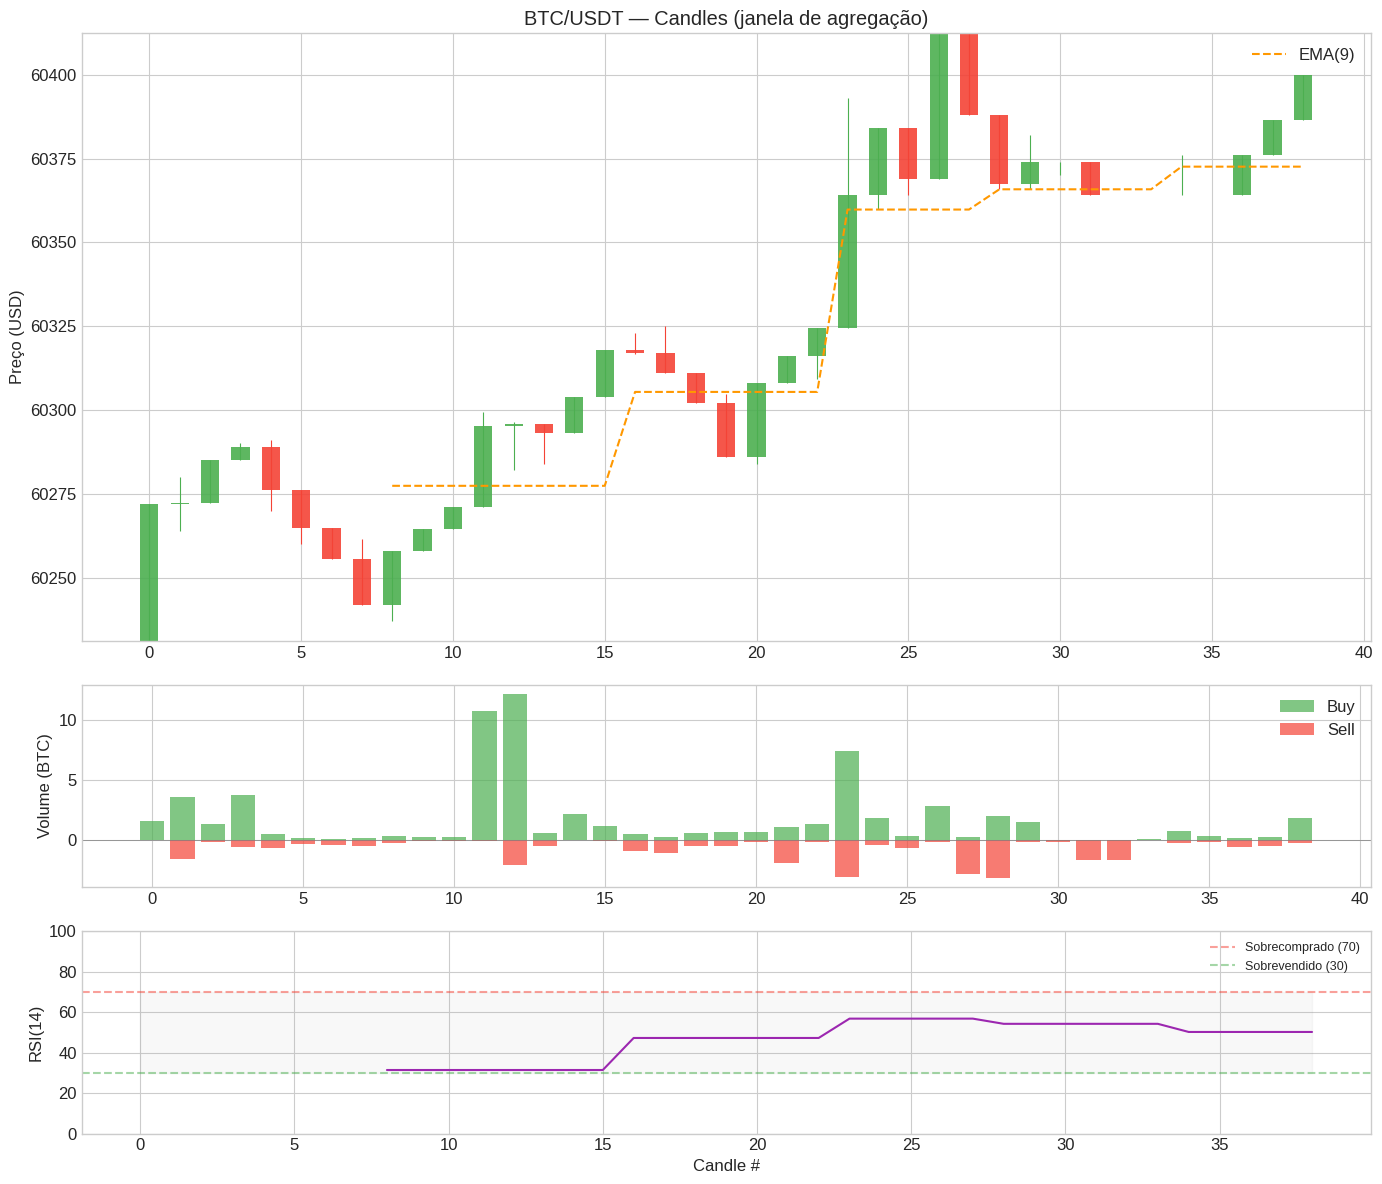

Salvo em: metrics/candles_chart.png


In [7]:
if not candles.empty:
    # Usa os candles do primeiro experimento disponível
    sample = candles.sort_values("window_start").tail(100)

    fig, axes = plt.subplots(3, 1, figsize=(14, 12), gridspec_kw={"height_ratios": [3, 1, 1]})

    # --- Gráfico de velas simplificado ---
    ax1 = axes[0]
    x = range(len(sample))
    colors_candle = ["#4CAF50" if c >= o else "#F44336"
                     for o, c in zip(sample["open"], sample["close"])]

    ax1.bar(x, sample["close"] - sample["open"], bottom=sample["open"],
            color=colors_candle, width=0.6, alpha=0.9)
    ax1.vlines(x, sample["low"], sample["high"], colors=colors_candle, linewidth=0.8)

    if sample["ema_9"].notna().any():
        ax1.plot(x, sample["ema_9"].values, color="#FF9800", linewidth=1.5,
                 label="EMA(9)", linestyle="--")
        ax1.legend()

    ax1.set_title(f"BTC/USDT — Candles (janela de agregação)")
    ax1.set_ylabel("Preço (USD)")

    # --- Volume com buy/sell ---
    ax2 = axes[1]
    if sample["buy_volume"].notna().any():
        ax2.bar(x, sample["buy_volume"], color="#4CAF50", alpha=0.7, label="Buy")
        ax2.bar(x, -sample["sell_volume"], color="#F44336", alpha=0.7, label="Sell")
        ax2.legend()
    else:
        ax2.bar(x, sample["volume"], color="#2196F3", alpha=0.7)
    ax2.set_ylabel("Volume (BTC)")
    ax2.axhline(y=0, color="gray", linewidth=0.5)

    # --- RSI ---
    ax3 = axes[2]
    if sample["rsi_14"].notna().any():
        ax3.plot(x, sample["rsi_14"].values, color="#9C27B0", linewidth=1.5)
        ax3.axhline(y=70, color="#F44336", linestyle="--", alpha=0.5, label="Sobrecomprado (70)")
        ax3.axhline(y=30, color="#4CAF50", linestyle="--", alpha=0.5, label="Sobrevendido (30)")
        ax3.fill_between(x, 30, 70, alpha=0.05, color="gray")
        ax3.set_ylim(0, 100)
        ax3.legend(fontsize=9)
    ax3.set_ylabel("RSI(14)")
    ax3.set_xlabel("Candle #")

    plt.tight_layout()
    plt.savefig(METRICS_DIR / "candles_chart.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Salvo em: metrics/candles_chart.png")

## 5. Tabela Resumo — média ± desvio-padrão entre rodadas

Cada configuração foi executada em **múltiplas repetições** (>= 3, requisito do enunciado). Aqui cada rodada vira uma observação (média de seus batches) e reportamos **média ± desvio-padrão** entre as rodadas. Esta é a tabela de resultados estatísticos do relatório.

In [8]:
if not perf.empty:
    # Extrai o número da rodada do label (ex: p2_w10_r3 -> 3)
    perf["run"] = perf["experiment_label"].str.extract(r'_r(\d+)$').astype(float)

    # 1) Resumo POR RODADA: cada rodada vira UMA observação (média dos seus batches)
    per_run = (perf.groupby(["partitions", "window_s", "run"], as_index=False)
                   .agg(throughput=("throughput_trades_per_sec", "mean"),
                        latency_p50=("latency_p50_ms", "mean"),
                        latency_p95=("latency_p95_ms", "mean"),
                        latency_p99=("latency_p99_ms", "mean"),
                        trades=("num_trades", "sum")))

    # 2) Estatística ENTRE RODADAS: média e desvio-padrão amostral (ddof=1)
    stats = (per_run.groupby(["partitions", "window_s"])
                    .agg(n_runs=("run", "nunique"),
                         throughput_avg=("throughput", "mean"),
                         throughput_std=("throughput", "std"),
                         latency_p50_avg=("latency_p50", "mean"),
                         latency_p50_std=("latency_p50", "std"),
                         latency_p95_avg=("latency_p95", "mean"),
                         latency_p95_std=("latency_p95", "std"))
                    .reset_index())
    stats.to_csv(METRICS_DIR / "summary_stats.csv", index=False)

    # Tabela formatada "média ± desvio" pronta para colar no relatório
    tabela = pd.DataFrame({
        "partições": stats["partitions"].astype(int),
        "janela (s)": stats["window_s"].astype(int),
        "rodadas": stats["n_runs"].astype(int),
        "vazão (trades/s)": [f"{m:.1f} ± {s:.1f}" for m, s in zip(stats["throughput_avg"], stats["throughput_std"].fillna(0))],
        "latência p50 (ms)": [f"{m:.0f} ± {s:.0f}" for m, s in zip(stats["latency_p50_avg"], stats["latency_p50_std"].fillna(0))],
        "latência p95 (ms)": [f"{m:.0f} ± {s:.0f}" for m, s in zip(stats["latency_p95_avg"], stats["latency_p95_std"].fillna(0))],
    })

    print("=" * 80)
    print("TABELA RESUMO — média ± desvio-padrão entre rodadas (>= 3 repetições)")
    print("=" * 80)
    display(tabela)
    print("\nSalvo em: metrics/summary_stats.csv (valores numéricos)")

TABELA RESUMO — média ± desvio-padrão entre rodadas (>= 3 repetições)


,partições,janela (s),rodadas,vazão (trades/s),latência p50 (ms),latência p95 (ms)
0,1,15,1,687.9 ± 0.0,181452 ± 0,213896 ± 0



Salvo em: metrics/summary_stats.csv (valores numéricos)


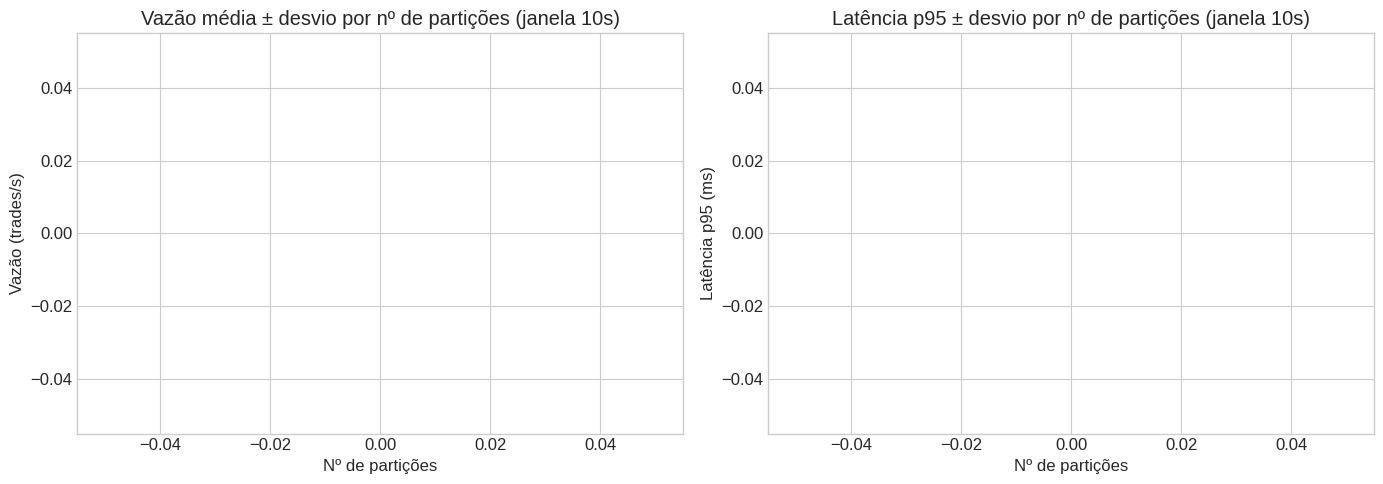

Salvo em: metrics/stats_error_bars.png


In [9]:
if not perf.empty:
    # Gráficos com BARRAS DE ERRO = desvio-padrão entre rodadas (janela 10s)
    s10 = stats[stats["window_s"] == 10].sort_values("partitions")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].bar(s10["partitions"].astype(int).astype(str), s10["throughput_avg"],
                yerr=s10["throughput_std"].fillna(0), capsize=6, color="#2196F3")
    axes[0].set_title("Vazão média ± desvio por nº de partições (janela 10s)")
    axes[0].set_xlabel("Nº de partições"); axes[0].set_ylabel("Vazão (trades/s)")

    axes[1].bar(s10["partitions"].astype(int).astype(str), s10["latency_p95_avg"],
                yerr=s10["latency_p95_std"].fillna(0), capsize=6, color="#FF9800")
    axes[1].set_title("Latência p95 ± desvio por nº de partições (janela 10s)")
    axes[1].set_xlabel("Nº de partições"); axes[1].set_ylabel("Latência p95 (ms)")

    plt.tight_layout()
    plt.savefig(METRICS_DIR / "stats_error_bars.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Salvo em: metrics/stats_error_bars.png")

## 6. Conclusões

**Throughput:** Descrever como a vazão variou com o número de partições e tamanho de janela.

**Latência:** Analisar a distribuição de latência fim-a-fim. Caudas longas (p99 muito acima do p50) indicam rajadas ou backpressure.

**Trade-off janela vs latência:** Janelas maiores acumulam mais trades por batch (maior throughput aparente) mas introduzem mais latência. Discutir o ponto ótimo encontrado.

**Escalabilidade horizontal:** Se o throughput cresceu linearmente com partições, o pipeline escala bem. Se não, identificar o gargalo (rede, CPU do Spark, serialização).

**Completude:** Gaps no trade_id indicam perda de mensagens. Relacionar com os cenários de teste.